In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)


In [2]:
t2012 = pd.read_csv('/mnt/user-data/uploads/Tabela5-sem_emprego_2012.csv', sep=';', encoding='utf-8-sig')
t2026 = pd.read_csv('/mnt/user-data/uploads/Tabela5-sem_emprego_2026.csv', sep=';', encoding='utf-8-sig')

# Converter vírgula decimal -> ponto e para float
for col in t2012.columns[3:]:
    t2012[col] = t2012[col].astype(str).str.replace(',', '.').astype(float)
for col in t2026.columns[3:]:
    t2026[col] = t2026[col].astype(str).str.replace(',', '.').astype(float)

t2012.head()


,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1)
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2


In [3]:
t2026.head()

,Sigla,Código,Estado,Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3


In [4]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")
print("Linhas:", comp.shape[0], "| Colunas:", comp.shape[1])
comp.head()


Linhas: 27 | Colunas: 7


,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1),Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3


In [5]:
comp["Var_mulheres_pp"] = comp["Desocupados - mulheres (2026 T1)"] - comp["Desocupados - mulheres (2012 T1)"]
comp["Var_homens_pp"] = comp["Desocupados - homens (2026 T1)"] - comp["Desocupados - homens (2012 T1)"]

comp_sorted = comp.sort_values("Var_mulheres_pp", ascending=False)
comp_sorted[["Sigla", "Estado", "Desocupados - mulheres (2012 T1)", "Desocupados - mulheres (2026 T1)",
             "Var_mulheres_pp", "Var_homens_pp"]]


,Sigla,Estado,Desocupados - mulheres (2012 T1),Desocupados - mulheres (2026 T1),Var_mulheres_pp,Var_homens_pp
20,RO,Rondônia,56.6,67.0,10.4,-10.4
26,TO,Tocantins,44.7,53.8,9.1,-9.1
24,SE,Sergipe,53.5,59.7,6.2,-6.2
19,RN,Rio Grande do Norte,49.0,51.8,2.8,-2.8
11,MS,Mato Grosso do Sul,52.8,54.7,1.9,-1.9
12,MT,Mato Grosso,55.9,57.2,1.3,-1.3
2,AM,Amazonas,52.5,53.2,0.7,-0.7
25,SP,São Paulo,54.6,53.8,-0.8,0.8
4,BA,Bahia,56.2,55.3,-0.9,0.9
7,ES,Espírito Santo,53.6,52.5,-1.1,1.1


In [6]:
raw = pd.read_excel('/mnt/user-data/uploads/Tabela_1_1_1.xls', sheet_name='2022', header=None)

# Linhas 8 a 40 (índice) trazem Brasil + Grandes Regiões + Estados; colunas 0 (local) e 1 (Total)
tab111 = raw.iloc[8:41, [0, 1]].copy()
tab111.columns = ["Estado", "Horas_semanais_total_2022"]
tab111["Estado"] = tab111["Estado"].str.strip()
tab111["Horas_semanais_total_2022"] = tab111["Horas_semanais_total_2022"].astype(float)

# Ficamos só com os 26 estados + DF (removendo Brasil e Grandes Regiões)
regioes = ["Brasil", "Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
tab111_estados = tab111[~tab111["Estado"].isin(regioes)].reset_index(drop=True)

print("Total de linhas (estados):", len(tab111_estados))
tab111_estados


Total de linhas (estados): 27


,Estado,Horas_semanais_total_2022
0,Rondônia,17.014162
1,Acre,13.606903
2,Amazonas,16.807290
3,Roraima,13.639257
4,Pará,16.474268
5,Amapá,13.586656
6,Tocantins,15.815781
7,Maranhão,16.669614
8,Piauí,17.960366
9,Ceará,19.499293


In [7]:
final = comp.merge(tab111_estados, on="Estado", how="left")

# Conferir se algum estado não casou (NaN na coluna de horas)
print("Estados sem correspondência:", final["Horas_semanais_total_2022"].isna().sum())

final[["Sigla", "Estado", "Var_mulheres_pp", "Var_homens_pp", "Horas_semanais_total_2022"]]


Estados sem correspondência: 0


,Sigla,Estado,Var_mulheres_pp,Var_homens_pp,Horas_semanais_total_2022
0,AC,Acre,-7.9,7.9,13.606903
1,AL,Alagoas,-6.0,6.0,20.217129
2,AM,Amazonas,0.7,-0.7,16.807290
3,AP,Amapá,-3.0,3.0,13.586656
4,BA,Bahia,-0.9,0.9,17.849776
5,CE,Ceará,-1.6,1.6,19.499293
6,DF,Distrito Federal,-6.9,6.9,15.096351
7,ES,Espírito Santo,-1.1,1.1,17.111106
8,GO,Goiás,-6.5,6.5,15.186471
9,MA,Maranhão,-1.9,1.9,16.669614


In [8]:
corr_nivel = final["Desocupados - mulheres (2026 T1)"].corr(final["Horas_semanais_total_2022"])
corr_variacao = final["Var_mulheres_pp"].corr(final["Horas_semanais_total_2022"])

print(f"Correlação (nível 2026 x horas domésticas 2022):   {corr_nivel:.3f}")
print(f"Correlação (variação 2012-2026 x horas domésticas): {corr_variacao:.3f}")


Correlação (nível 2026 x horas domésticas 2022):   -0.105
Correlação (variação 2012-2026 x horas domésticas): 0.098


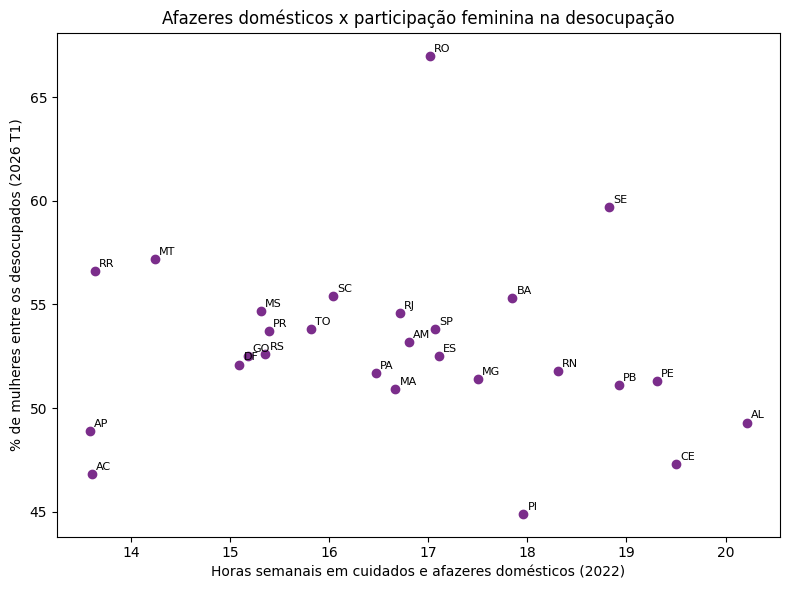

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(final["Horas_semanais_total_2022"], final["Desocupados - mulheres (2026 T1)"], color="#7B2D8B")
for _, row in final.iterrows():
    ax.annotate(row["Sigla"],
                (row["Horas_semanais_total_2022"], row["Desocupados - mulheres (2026 T1)"]),
                fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Horas semanais em cuidados e afazeres domésticos (2022)")
ax.set_ylabel("% de mulheres entre os desocupados (2026 T1)")
ax.set_title("Afazeres domésticos x participação feminina na desocupação")
plt.tight_layout()
plt.show()
